# Attractor convergence

This notebook computes convergence metrics comparing SD, null, uniform, and random groupings across Boolean network models.

Results are cached to CSV to allow rapid iteration on figures.

Generates figures 5, 6, s3, and s4.

In [ ]:
import pandas as pd

import sdmarkov.plotting.config as pc
from sdmarkov.basins import get_convergence_matrix
from sdmarkov.matrix_operations import get_rms_diff, get_kld, get_confusion_matrix
from sdmarkov.transition_matrix import get_uniform_matrix
from sdmarkov.analysis.model_context import iter_model_contexts
from sdmarkov.analysis.collect import generate_dataframe
from sdmarkov.analysis.postprocessing import add_classification_metrics, network_level_metrics_df
from sdmarkov.plotting.figures import plot_violin_figure, plot_distribution_figure, save_figure

In [2]:
IMPORT_CSV = False
REBUILD_CONTEXTS = False
DEBUG = False

CACHE_DIR = "../.cache/model_contexts"
CSV_FILE = "../results/attractor_convergence.csv"

# Parameters for building contexts
MODEL_DIRECTORY = "../models/random_nk3"
UPDATE = "asynchronous"
N_RANDOM = 30 # number of random models
NSQUARE_STEPS = 20 # number of steps for nsquare

# Figure configuration
FIGURE_DIR = "../results/figures"

MAIN_FIGURE_ID_1 = "5"
SUP_FIGURE_ID_1 = "s3"
METRICS_1 = ["precision", "specificity"]
METHODS_1 = None # plot all methods

MAIN_FIGURE_ID_2 = "6"
SUP_FIGURE_ID_2 = "s4"
METRICS_2 = ["rmsd", "kld"]
METHODS_2 = None # plot all methods
LIM = {"kld": (0, 1.5)}

## Data generation or loading

In [3]:
# --- Experiment-specific analysis ---
def get_data_convergence(
    context,
    DEBUG=False,
):
    """
    Compute convergence comparison metrics for a single Boolean network model.

    Parameters
    ----------
    context : ModelContext
        Pre-built model context.
    DEBUG : bool, optional
        Enable verbose output in lower-level metric computations.

    Returns
    -------
    pd.DataFrame
        Long-format DataFrame with one row per method (and per random run).
        Returns an empty DataFrame if the model has fewer than two attractors.
    """

    rows = []

    # Unpack model context
    model_name = context.model_name
    update = context.update
    n_states = context.n_states
    predicted_attractor_indices = context.predicted_attractor_indices
    n_attractors = context.n_attractors
    T_inf = context.T_inf
    Tsd_inf_expanded = context.Tsd_inf_expanded
    Tnull_inf_expanded = context.Tnull_inf_expanded
    n_random = context.random.n_random
    Trandom_inf_expanded_list = context.random.Trandom_inf_expanded

    # filter out networks with less than 2 attractors
    if n_attractors < 2:
        return pd.DataFrame(rows)

    # Actual
    T_conv = get_convergence_matrix(T_inf, predicted_attractor_indices, DEBUG=DEBUG)

    # Reference
    uniform_conv = get_uniform_matrix(n_states, n_attractors)

    # MC
    sd_conv = get_convergence_matrix(Tsd_inf_expanded, predicted_attractor_indices, DEBUG=DEBUG)
    null_conv = get_convergence_matrix(Tnull_inf_expanded, predicted_attractor_indices, DEBUG=DEBUG)

    # Helper to add metrics to rows
    def _add_row(method, conv_matrix, run=None):
        rmsd_val = get_rms_diff(T_conv, conv_matrix, partial=True, DEBUG=DEBUG)
        kld_val = get_kld(T_conv, conv_matrix, partial=True, DEBUG=DEBUG)
        TP, FP, TN, FN = get_confusion_matrix(T_conv, conv_matrix, partial=True, DEBUG=DEBUG)

        rows.append({
            "model": model_name,
            "method": method,
            "run": run,
            "rmsd": rmsd_val,
            "kld": kld_val,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "n_states": n_states,
            "n_attractors": n_attractors,
            "update_scheme": update
        })

    # Deterministic/reference methods
    _add_row("sd_mc", sd_conv)
    _add_row("null_mc", null_conv)
    _add_row("ref", uniform_conv)

    # Random runs
    for i in range(n_random):
        Trandom_inf_expanded = Trandom_inf_expanded_list[i]
        random_conv = get_convergence_matrix(Trandom_inf_expanded, predicted_attractor_indices, DEBUG=DEBUG)
        _add_row("random_mc", random_conv, run=i)

    return pd.DataFrame(rows)

In [4]:
if IMPORT_CSV:
    df = pd.read_csv(CSV_FILE)
    print(f"Loaded cached results from {CSV_FILE}.")
else:
    ctxs = iter_model_contexts(model_directory=MODEL_DIRECTORY,
                               update=UPDATE,
                               nsquare_steps=NSQUARE_STEPS,
                               n_random=N_RANDOM,
                               cache_dir=CACHE_DIR,
                               force_rebuild=REBUILD_CONTEXTS,
                               DEBUG=DEBUG,
                               )

    df = generate_dataframe(
        model_contexts=ctxs,
        data_function=get_data_convergence,
        schema={
            "TP": int,
            "FP": int,
            "TN": int,
            "FN": int,
            "n_states": int,
            "n_attractors": int,
            "run": "Int64",
        },
        DEBUG=DEBUG,
    )
    df.to_csv(CSV_FILE, index=False)
    print(f"Saved results to {CSV_FILE}.")

Preparing contexts for 100 models
[  1/100] n010_000.bnet
[  2/100] n010_001.bnet
[  3/100] n010_002.bnet
[  4/100] n010_003.bnet
[  5/100] n010_004.bnet
[  6/100] n010_005.bnet
[  7/100] n010_006.bnet
[  8/100] n010_007.bnet
[  9/100] n010_008.bnet
[ 10/100] n010_009.bnet
[ 11/100] n010_010.bnet
[ 12/100] n010_011.bnet
[ 13/100] n010_012.bnet
[ 14/100] n010_013.bnet
[ 15/100] n010_014.bnet
[ 16/100] n010_015.bnet
[ 17/100] n010_016.bnet
[ 18/100] n010_017.bnet
[ 19/100] n010_018.bnet
[ 20/100] n010_019.bnet
[ 21/100] n010_020.bnet
[ 22/100] n010_021.bnet
[ 23/100] n010_022.bnet
[ 24/100] n010_023.bnet
[ 25/100] n010_024.bnet
[ 26/100] n010_025.bnet
[ 27/100] n010_026.bnet
[ 28/100] n010_027.bnet
[ 29/100] n010_028.bnet
[ 30/100] n010_029.bnet
[ 31/100] n010_030.bnet
[ 32/100] n010_031.bnet
[ 33/100] n010_032.bnet
[ 34/100] n010_033.bnet
[ 35/100] n010_034.bnet
[ 36/100] n010_035.bnet
[ 37/100] n010_036.bnet
[ 38/100] n010_037.bnet
[ 39/100] n010_038.bnet
[ 40/100] n010_039.bnet
[ 41/1

In [5]:
print("Preview of results DataFrame:")
display(df.head())

print("\nDataFrame shape:", df.shape)
print("Methods present:", df.method.unique())
print("Number of unique networks:", df.model.nunique())

Preview of results DataFrame:


,model,method,run,rmsd,kld,TP,FP,TN,FN,n_states,n_attractors,update_scheme
0,n010_000.bnet,sd_mc,<NA>,0.073292,0.015284,1408,0,640,0,1024,2,asynchronous
1,n010_000.bnet,null_mc,<NA>,0.423820,0.478137,1408,576,64,0,1024,2,asynchronous
2,n010_000.bnet,ref,<NA>,0.441869,0.521459,1408,640,0,0,1024,2,asynchronous
3,n010_000.bnet,random_mc,0,0.421663,0.474490,1408,576,64,0,1024,2,asynchronous
4,n010_000.bnet,random_mc,1,0.426781,0.483176,1408,576,64,0,1024,2,asynchronous



DataFrame shape: (1518, 12)
Methods present: ['sd_mc' 'null_mc' 'ref' 'random_mc']
Number of unique networks: 46


## Data analysis

In [6]:
# filter out networks with a single attractor
df_multi = df[df["n_attractors"] > 1].copy()

# add precision, recall, specificity, and NPV
df_multi = add_classification_metrics(df_multi)

print("Added classification metrics")
print("DataFrame shape:", df_multi.shape)
print("Methods present:", df_multi.method.unique())
print("Number of unique networks:", df_multi.model.nunique())

display(df_multi.head())

Added classification metrics
DataFrame shape: (1518, 16)
Methods present: ['sd_mc' 'null_mc' 'ref' 'random_mc']
Number of unique networks: 46


,model,method,run,rmsd,kld,TP,FP,TN,FN,n_states,n_attractors,update_scheme,precision,recall,specificity,npv
0,n010_000.bnet,sd_mc,<NA>,0.073292,0.015284,1408,0,640,0,1024,2,asynchronous,1.000000,1.0,1.0,1.0
1,n010_000.bnet,null_mc,<NA>,0.423820,0.478137,1408,576,64,0,1024,2,asynchronous,0.709677,1.0,0.1,1.0
2,n010_000.bnet,ref,<NA>,0.441869,0.521459,1408,640,0,0,1024,2,asynchronous,0.687500,1.0,0.0,NaN
3,n010_000.bnet,random_mc,0,0.421663,0.474490,1408,576,64,0,1024,2,asynchronous,0.709677,1.0,0.1,1.0
4,n010_000.bnet,random_mc,1,0.426781,0.483176,1408,576,64,0,1024,2,asynchronous,0.709677,1.0,0.1,1.0


In [7]:
df_metrics = network_level_metrics_df(df=df_multi)

print("Preview of network-level metrics DataFrame:")
display(df_metrics.head())

print("\nDataFrame shape:", df_metrics.shape)
print("Methods present:", df_metrics.method.unique())
print("Number of unique networks:", df_metrics.model.nunique())

print("\nNetwork-level classification metrics:")
metrics = ["rmsd", "kld", "precision", "recall", "specificity", "npv"]
summary = (
    df_metrics
    .groupby("method")[metrics]
    .agg(["mean", "min", "median", "max"])
)

display(summary)

Preview of network-level metrics DataFrame:


,model,method,rmsd,kld,TP,FP,TN,FN,n_states,n_attractors,update_scheme,precision,recall,specificity,npv
0,n010_000.bnet,null_mc,0.423820,0.478137,1408.0,576.0,64.0,0.0,1024.0,2.0,asynchronous,0.709677,1.0,0.100000,1.0
1,n010_000.bnet,random_mc,0.423475,0.477561,1408.0,576.0,64.0,0.0,1024.0,2.0,asynchronous,0.709677,1.0,0.100000,1.0
2,n010_000.bnet,ref,0.441869,0.521459,1408.0,640.0,0.0,0.0,1024.0,2.0,asynchronous,0.687500,1.0,0.000000,NaN
3,n010_000.bnet,sd_mc,0.073292,0.015284,1408.0,0.0,640.0,0.0,1024.0,2.0,asynchronous,1.000000,1.0,1.000000,1.0
4,n010_001.bnet,null_mc,0.304786,1.068623,116.0,180.0,24.0,0.0,64.0,5.0,asynchronous,0.391892,1.0,0.117647,1.0



DataFrame shape: (184, 15)
Methods present: ['null_mc' 'random_mc' 'ref' 'sd_mc']
Number of unique networks: 46

Network-level classification metrics:


rmsd                                     kld            \
               mean       min    median       max      mean       min   
method                                                                  
null_mc    0.299748  0.000000  0.324377  0.663478  0.512765  0.000000   
random_mc  0.295883  0.000000  0.309780  0.663313  0.501677  0.000000   
ref        0.372703  0.144227  0.379120  0.500000  0.638685  0.047403   
sd_mc      0.129956  0.000000  0.137484  0.477810  0.117395  0.000000   

                              precision            ... recall       \
             median       max      mean       min  ... median  max   
method                                             ...               
null_mc    0.471609  1.416023  0.741072  0.256000  ...    1.0  1.0   
random_mc  0.471292  1.410800  0.743558  0.256000  ...    1.0  1.0   
ref        0.693147  1.386294  0.643828  0.250000  ...    1.0  1.0   
sd_mc      0.070566  0.625135  0.972632  0.816901  ...    1.0  1.0   

          specificity                           npv                   
                 mean       min    median  max mean  min median  max  
method                                                                
null_mc      0.273529  0.005102  0.133929  1.0  1.0  1.0    1.0  1.0  
random_mc    0.279075  0.005102  0.133929  1.0  1.0  1.0    1.0  1.0  
ref          0.000000  0.000000  0.000000  0.0  NaN  NaN    NaN  NaN  
sd_mc        0.903626  0.040816  0.987291  1.0  1.0  1.0    1.0  1.0  

[4 rows x 24 columns]

## Plotting

In [8]:
pc.apply_style()

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


PosixPath('../results/figures/Figure_5_Attractor_reachability.png')

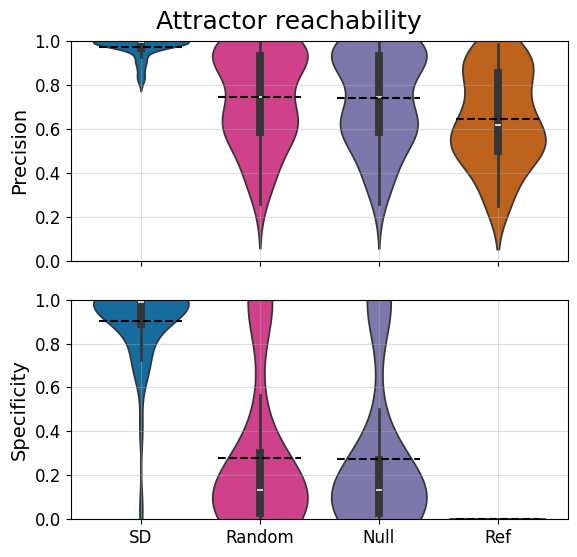

In [9]:
fig1_1 = plot_violin_figure(df_metrics, metrics=METRICS_1, figure_id=MAIN_FIGURE_ID_1)

save_figure(fig1_1, figure_id=MAIN_FIGURE_ID_1, outdir=FIGURE_DIR)

/home/troonmel/SDMarkov/sdmarkov/src/sdmarkov/plotting/figures.py:181: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


PosixPath('../results/figures/Figure_s3_Attractor_reachability.png')

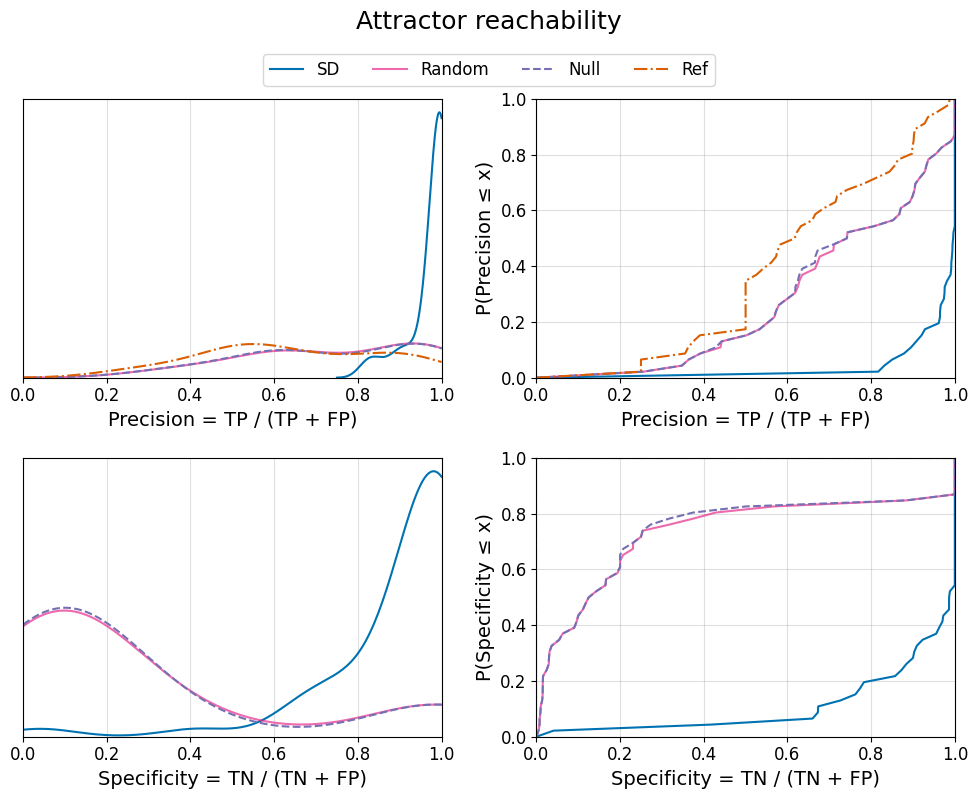

In [10]:
fig1_2 = plot_distribution_figure(df_metrics, metrics=METRICS_1, figure_id=SUP_FIGURE_ID_1)

save_figure(fig1_2, figure_id=SUP_FIGURE_ID_1, outdir=FIGURE_DIR)

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


PosixPath('../results/figures/Figure_6_Convergence_probabilities.png')

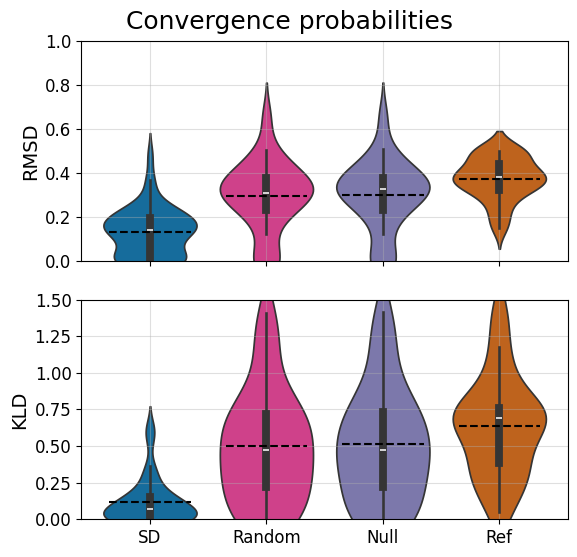

In [11]:
fig2_1 = plot_violin_figure(df_metrics, metrics=METRICS_2, figure_id=MAIN_FIGURE_ID_2, lim=LIM)

save_figure(fig2_1, figure_id=MAIN_FIGURE_ID_2, outdir=FIGURE_DIR)

PosixPath('../results/figures/Figure_s4_Convergence_probabilities.png')

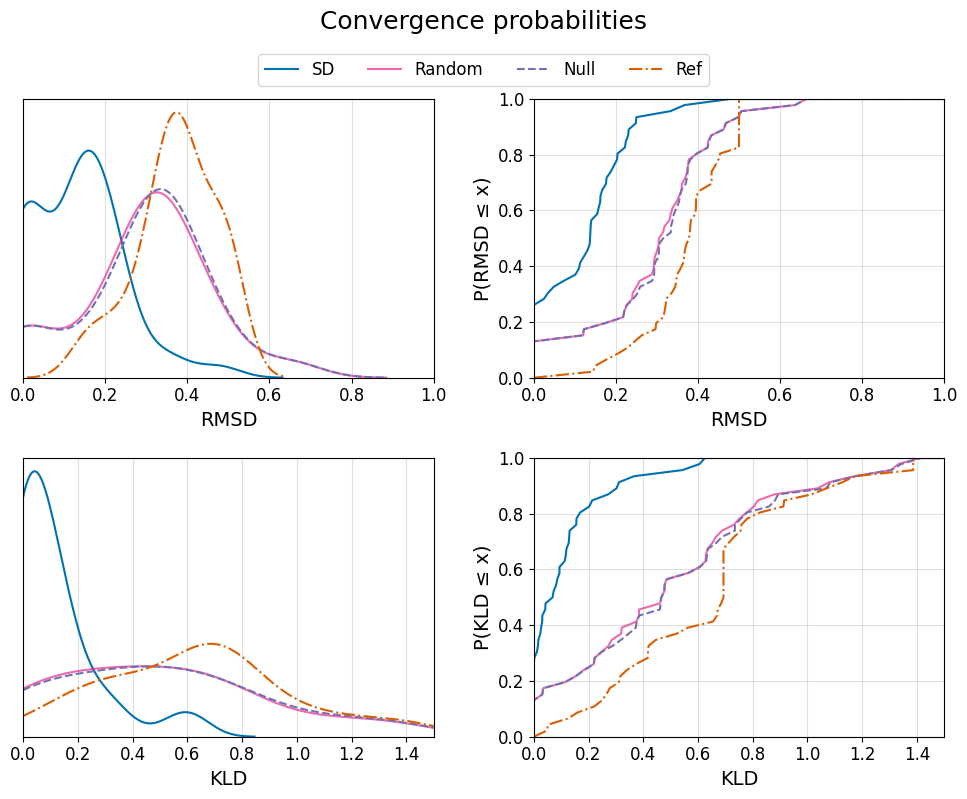

In [12]:
fig2_2 = plot_distribution_figure(df_metrics, metrics=METRICS_2, figure_id=SUP_FIGURE_ID_2, lim=LIM)

save_figure(fig2_2, figure_id=SUP_FIGURE_ID_2, outdir=FIGURE_DIR)